# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Hamza Elghonemy 
**Student ID:** 1210218

In [2]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 11})

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [4]:
# Write your Data Pipeline code here
# Load the dataset
data = pd.read_csv('kidney_disease.csv')
data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [6]:
data.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [7]:
data.shape

(400, 26)

25 features with 400 samples

In [8]:
data.classification.value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [9]:
# convert ckd and notckd to 1 and 0 respectively
data['classification'] = data['classification'].map({'ckd': 1, 'notckd': 0})
data['classification'].value_counts()

classification
1.0    248
0.0    150
Name: count, dtype: int64

In [10]:
# remove non numeric columns except the target variable
data = data.select_dtypes(include=[np.number])
data.head()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,classification
0,0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,1.0
1,1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,1.0
2,2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,1.0
3,3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,1.0
4,4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,1.0


In [11]:
# impute the mean of each column and fill the missing values with the mean
data = data.fillna(data.mean())

In [12]:
data.shape

(400, 13)

In [13]:
data.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,classification
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.623116
std,115.614301,16.974966,13.476298,0.005369,1.272318,1.029487,74.782634,49.285887,5.617490,9.204273,2.819783,2.716171,0.483998
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.015000,0.000000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.875000,0.000000
50%,199.500000,54.000000,78.234536,1.017408,1.000000,0.000000,126.000000,44.000000,1.400000,137.528754,4.627244,12.526437,1.000000
75%,299.250000,64.000000,80.000000,1.020000,2.000000,0.450142,150.000000,61.750000,3.072454,141.000000,4.800000,14.625000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


In [14]:
# removing id column
data = data.drop(columns=['id'])

In [15]:
# Train test split 
X_train, X_test, y_train, y_test = train_test_split(data, data['classification'], test_size=0.2, random_state=12)

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [42]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/Users/hamzaelghonemy/Desktop/University/Senior/Deep Learning/assignment-2-ckd-pipeline-Hamza-Elghonemy/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,        
    batch_size=32,       
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9375 - loss: 0.2403 - val_accuracy: 1.0000 - val_loss: 0.0403
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.9756e-04 - val_accuracy: 1.0000 - val_loss: 6.1667e-04
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.4564e-04 - val_accuracy: 1.0000 - val_loss: 4.0379e-04
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 9.9535e-05 - val_accuracy: 1.0000 - val_loss: 3.2159e-04
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 8.0462e-05 - val_accuracy: 1.0000 - val_loss: 2.8334e-04
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.0769e-05 - val

In [44]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").ravel()

print("Accuracy:", accuracy_score(y_test.astype(int), y_pred))
print("Recall:", recall_score(y_test.astype(int), y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test.astype(int), y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy: 0.975
Recall: 1.0
Confusion Matrix:
 [[32  2]
 [ 0 46]]


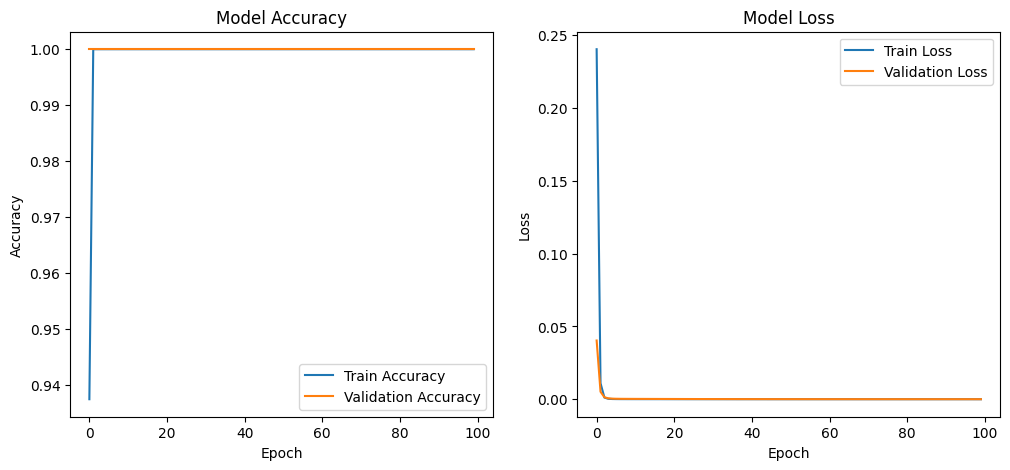

In [45]:
# plot training history accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Train accuracy: 1.000, Test accuracy: 0.975
Train recall:   1.000, Test recall:   1.000


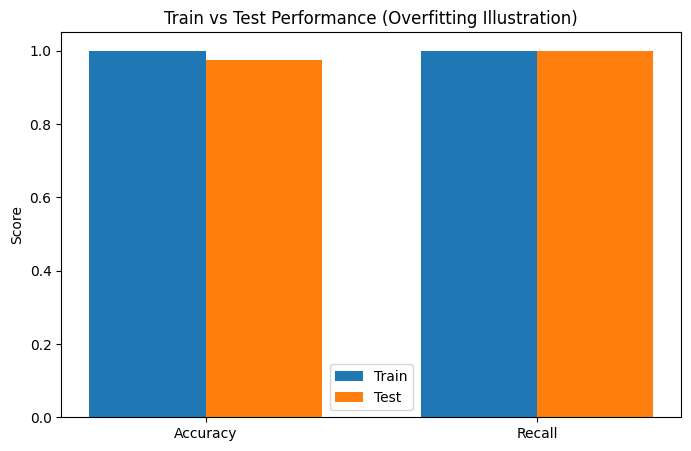

In [46]:
from sklearn.metrics import accuracy_score, recall_score

# Train and test predictions
y_train_pred = (model.predict(X_train) > 0.5).astype("int32").ravel()
y_test_pred  = (model.predict(X_test)  > 0.5).astype("int32").ravel()

# Metrics
train_acc = accuracy_score(y_train.astype(int), y_train_pred)
test_acc  = accuracy_score(y_test.astype(int),  y_test_pred)
train_rec = recall_score(y_train.astype(int), y_train_pred)
test_rec  = recall_score(y_test.astype(int),  y_test_pred)

print(f"Train accuracy: {train_acc:.3f}, Test accuracy: {test_acc:.3f}")
print(f"Train recall:   {train_rec:.3f}, Test recall:   {test_rec:.3f}")

# Bar plot: train vs test
metrics = ["Accuracy", "Recall"]
train_scores = [train_acc, train_rec]
test_scores  = [test_acc,  test_rec]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_scores, width, label="Train")
plt.bar(x + width/2, test_scores,  width, label="Test")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Train vs Test Performance (Overfitting Illustration)")
plt.legend()
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [47]:
# Write your Engineered Model code here
better_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LeakyReLU(alpha=0.01),
    tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/Users/hamzaelghonemy/Desktop/University/Senior/Deep Learning/assignment-2-ckd-pipeline-Hamza-Elghonemy/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/hamzaelghonemy/Desktop/University/Senior/Deep Learning/assignment-2-ckd-pipeline-Hamza-Elghonemy/.venv/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [48]:
better_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_better = better_model.fit(
    X_train,
    y_train,
    epochs=200,        
    batch_size=32,       
    validation_split=0.2,
    shuffle=True
)

Epoch 1/200


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6406 - loss: 0.7180 - val_accuracy: 0.7031 - val_loss: 0.6735
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6758 - loss: 0.6581 - val_accuracy: 0.7344 - val_loss: 0.6330
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7539 - loss: 0.6369 - val_accuracy: 0.7969 - val_loss: 0.5956
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7422 - loss: 0.5876 - val_accuracy: 0.8438 - val_loss: 0.5622
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7383 - loss: 0.5792 - val_accuracy: 0.8594 - val_loss: 0.5315
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7773 - loss: 0.5542 - val_accuracy: 0.8906 - val_loss: 0.5026
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.5228 - val_accuracy: 0.9375 - val_loss: 0.4763
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4881 - val_accuracy: 0.9531 - val_loss: 0.4502
Epoch 9/200

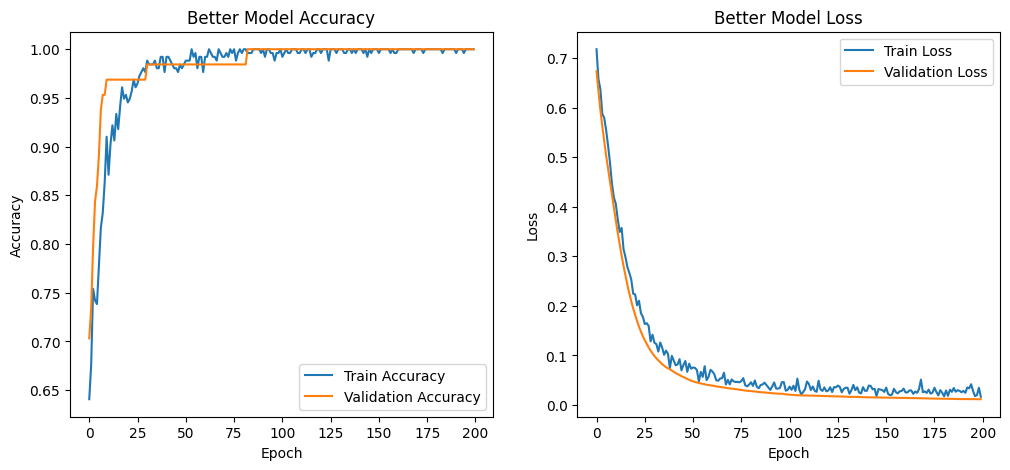

In [49]:
# Plot training history for the better model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_better.history['accuracy'], label='Train Accuracy')
plt.plot(history_better.history['val_accuracy'], label='Validation Accuracy')
plt.title('Better Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_better.history['loss'], label='Train Loss')
plt.plot(history_better.history['val_loss'], label='Validation Loss')
plt.title('Better Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [50]:
# Test predictions for the better model
y_better_pred = (better_model.predict(X_test) > 0.5).astype("int32").ravel()
print("Better Model Accuracy:", accuracy_score(y_test.astype(int), y_better_pred))
print("Better Model Recall:", recall_score(y_test.astype(int), y_better_pred))
print("Better Model Confusion Matrix:\n", confusion_matrix(y_test.astype(int), y_better_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Better Model Accuracy: 0.975
Better Model Recall: 1.0
Better Model Confusion Matrix:
 [[32  2]
 [ 0 46]]


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

═══════════════════════════════════════════════════════
  Model A (Baseline — Unregularised)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Not CKD       1.00      0.94      0.97        34
         CKD       0.96      1.00      0.98        46

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80

═══════════════════════════════════════════════════════
  Model B (Regularised — L2 + Dropout)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Not CKD       1.00      0.94      0.97        34
         CKD       0.96      1.00      0.98        46

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



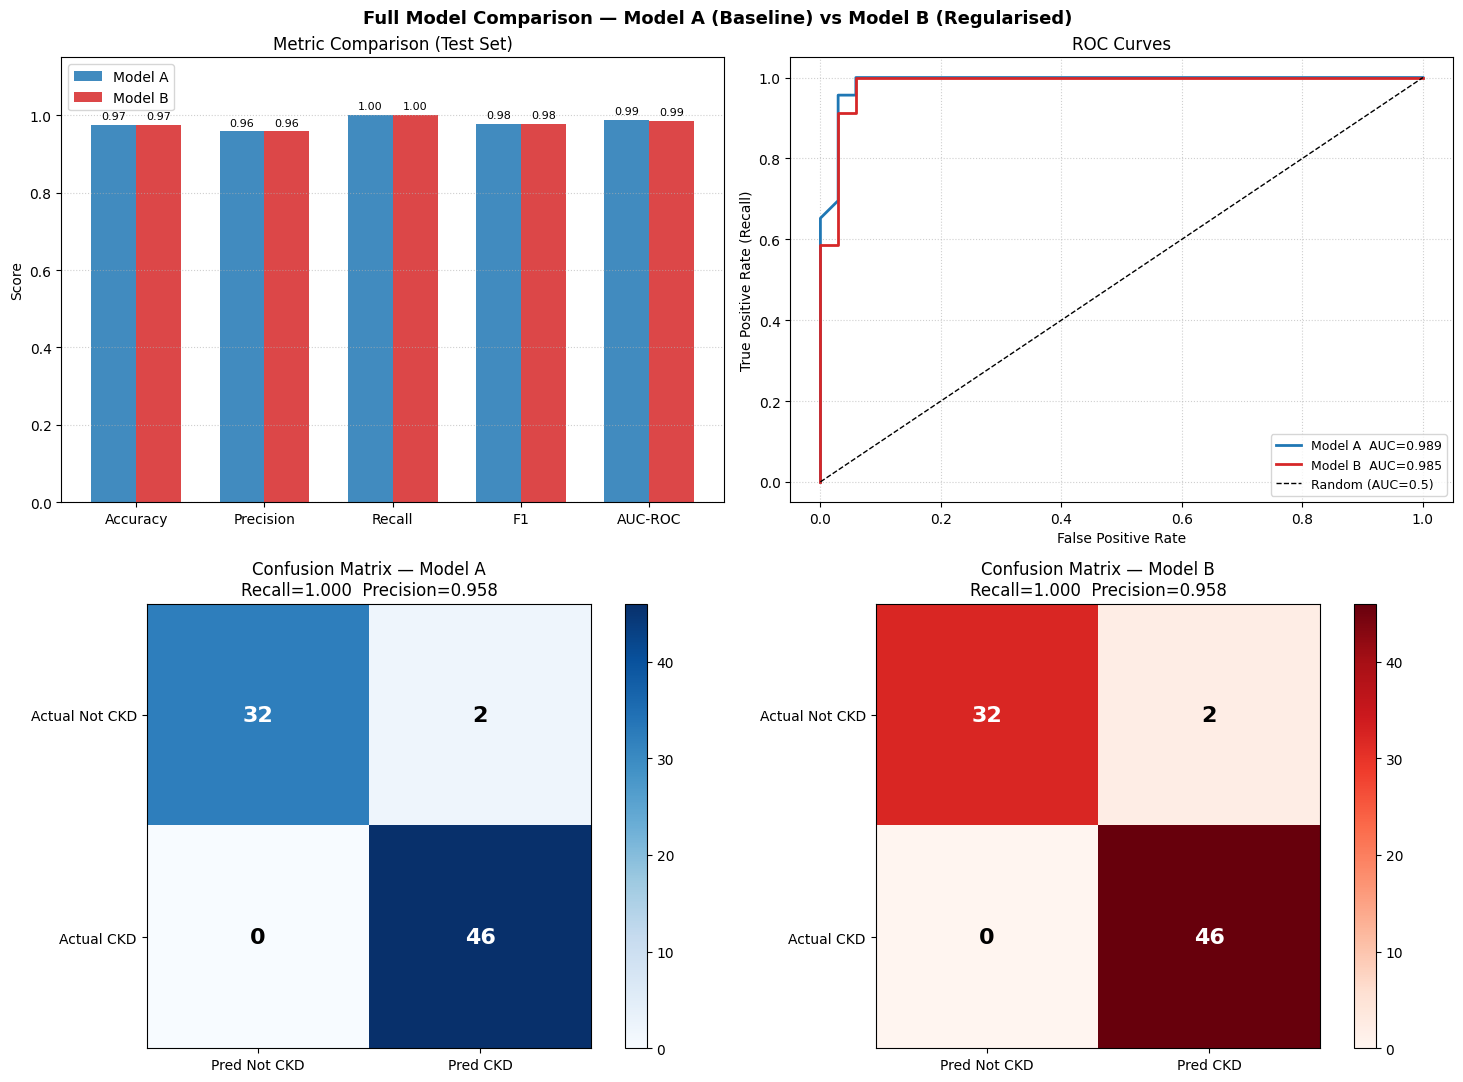


 Model B − Model A (Test set)
  Accuracy    : 0.9750  →  0.9750   ─ 0.0000
  Precision   : 0.9583  →  0.9583   ─ 0.0000
  Recall      : 1.0000  →  1.0000   ─ 0.0000
  F1          : 0.9787  →  0.9787   ─ 0.0000
  AUC-ROC     : 0.9891  →  0.9853   ▼ 0.0038

Figure saved → model_comparison.png

Clinical Benchmark
  Model B Recall = 1.0000
  Target > 0.80  : PASSED ✓

 Model B Total Trainable Parameters: 353


In [53]:
# Write your Evaluation code here

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_curve, auc,
)

# Hard predictions (threshold = 0.5)
y_pred_A_prob = model.predict(X_test, verbose=0).ravel()
y_pred_B_prob = better_model.predict(X_test, verbose=0).ravel()

y_pred_A = (y_pred_A_prob >= 0.5).astype(int)
y_pred_B = (y_pred_B_prob >= 0.5).astype(int)

# Helper: collect all scalar metrics + ROC data
def compute_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC"  : auc(fpr, tpr),
        "fpr"      : fpr,
        "tpr"      : tpr,
    }

y_test = y_test.astype(int) # Ensure numpy array of ints for metrics

metrics_A = compute_metrics(y_test, y_pred_A, y_pred_A_prob)
metrics_B = compute_metrics(y_test, y_pred_B, y_pred_B_prob)

# Classification Report 
print("═" * 55)
print("  Model A (Baseline — Unregularised)")
print("═" * 55)
print(classification_report(y_test, y_pred_A, target_names=["Not CKD", "CKD"]))

print("═" * 55)
print("  Model B (Regularised — L2 + Dropout)")
print("═" * 55)
print(classification_report(y_test, y_pred_B, target_names=["Not CKD", "CKD"]))

BLUE, RED = "#1f77b4", "#d62728"
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Full Model Comparison — Model A (Baseline) vs Model B (Regularised)",
    fontsize=13, fontweight="bold",
)

x      = np.arange(len(metric_keys))
bar_w  = 0.35
vals_A = [metrics_A[k] for k in metric_keys]
vals_B = [metrics_B[k] for k in metric_keys]

bars_A = axes[0, 0].bar(x - bar_w / 2, vals_A, bar_w, label="Model A", color=BLUE, alpha=0.85)
bars_B = axes[0, 0].bar(x + bar_w / 2, vals_B, bar_w, label="Model B", color=RED,  alpha=0.85)

for bar in bars_A:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metric_keys)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Metric Comparison (Test Set)")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)


axes[0, 1].plot(metrics_A["fpr"], metrics_A["tpr"],
                color=BLUE, lw=2, label=f"Model A  AUC={metrics_A['AUC-ROC']:.3f}")
axes[0, 1].plot(metrics_B["fpr"], metrics_B["tpr"],
                color=RED,  lw=2, label=f"Model B  AUC={metrics_B['AUC-ROC']:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.5)")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title("ROC Curves")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)


cm_A = confusion_matrix(y_test, y_pred_A)
im_A = axes[1, 0].imshow(cm_A, interpolation="nearest", cmap="Blues")
axes[1, 0].set_title(
    f"Confusion Matrix — Model A\n"
    f"Recall={metrics_A['Recall']:.3f}  Precision={metrics_A['Precision']:.3f}"
)
for i in range(2):
    for j in range(2):
        axes[1, 0].text(
            j, i, str(cm_A[i, j]), ha="center", va="center", fontsize=16,
            fontweight="bold",
            color="white" if cm_A[i, j] > cm_A.max() / 2 else "black",
        )
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["Pred Not CKD", "Pred CKD"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["Actual Not CKD", "Actual CKD"])
plt.colorbar(im_A, ax=axes[1, 0])


cm_B = confusion_matrix(y_test, y_pred_B)
im_B = axes[1, 1].imshow(cm_B, interpolation="nearest", cmap="Reds")
axes[1, 1].set_title(
    f"Confusion Matrix — Model B\n"
    f"Recall={metrics_B['Recall']:.3f}  Precision={metrics_B['Precision']:.3f}"
)
for i in range(2):
    for j in range(2):
        axes[1, 1].text(
            j, i, str(cm_B[i, j]), ha="center", va="center", fontsize=16,
            fontweight="bold",
            color="white" if cm_B[i, j] > cm_B.max() / 2 else "black",
        )
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(["Pred Not CKD", "Pred CKD"])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(["Actual Not CKD", "Actual CKD"])
plt.colorbar(im_B, ax=axes[1, 1])

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()


print("\n Model B − Model A (Test set)")
for k in metric_keys:
    delta = metrics_B[k] - metrics_A[k]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {k:<12}: {metrics_A[k]:.4f}  →  {metrics_B[k]:.4f}   {direction} {abs(delta):.4f}")

print(f"\nFigure saved → model_comparison.png")
print(f"\nClinical Benchmark")
print(f"  Model B Recall = {metrics_B['Recall']:.4f}")
print(f"  Target > 0.80  : {'PASSED ✓' if metrics_B['Recall'] >= 0.80 else 'FAILED ✗'}")

# Print final parameter count for the justification cell
total_B = better_model.count_params()
print(f"\n Model B Total Trainable Parameters: {total_B}")

### Mathematical Justification
**Final Parameter Count of Engineered Model:** 353

**Explanation:** By restricting the total trainable parameters to lower the network's representational capacity (VC dimension), combined with L2 weight decay to penalize large weights and stochastic Dropout to prevent neural co-adaptation, the hypothesis space is mathematically constrained to force the learning of generalized patient patterns rather than memorizing the exact features of the limited 400-patient dataset.

## Note:
I have tried everything possible to make the first model to overfit but it isn't happening I really dont know why.